# Proyek Analisis Data: Air Quality Dataset
- **Nama:** Steven Wijaya Lim
- **Email:** cdcc010d6y2705@student.devacademy.id
- **ID Dicoding:** CDCC010D6Y2705

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Faktor musiman apa yang menyebabkan rata-rata konsentrasi PM2.5 meningkat lebih dari 25% di seluruh stasiun Beijing pada periode musim dingin (November-Februari) dibandingkan musim panas (Juni-Agustus) sepanjang tahun 2013-2017, sehingga pemerintah dapat merancang kebijakan pembatasan emisi yang tepat sasaran pada bulan-bulan kritis tersebut?

- **Pertanyaan 2:** Stasiun pemantau mana di Beijing yang mencatat rata-rata konsentrasi PM2.5 tertinggi dan terendah selama periode 2013-2017, dan seberapa besar perbedaan (gap) konsentrasinya, agar otoritas lingkungan dapat memprioritaskan alokasi intervensi pengendalian polusi pada wilayah yang paling membutuhkan?

## Import Semua Packages/Library yang Digunakan

In [20]:
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd
import numpy as np
import glob

## Data Wrangling

### Gathering Data

#### Load df Air Quality Dataset

In [21]:
# Mmemuat path data dan seluruh file
path = 'data'
all_files = glob.glob(f"{path}/*.csv")

# Menampung setiap dataframe ke dalam list
df_list = [pd.read_csv(filename) for filename in all_files]

# Menggabungkan semua dataframe menjadi satu
df = pd.concat(df_list, ignore_index=True)

# Menampilkan informasi ukuran dan 5 baris pertama data dan describe data
print("Total ukuran data:", df.shape)
df.head()

# Simpan data hasil gabungan ke csv dalam folder dashboard
df.to_csv("dashboard/main_data.csv", index=False)

Total ukuran data: (420768, 18)


**Insight:** (Opsional)
- Struktur Data: Dataset ini merupakan data deret waktu (time-series) yang mencatat indikator kualitas udara dan kondisi meteorologi setiap jam di berbagai lokasi stasiun.
- Variabel Analisis: Terdapat kombinasi parameter polutan (gas dan partikulat) serta variabel cuaca yang memungkinkan analisis korelasi antara kondisi alam dengan tingkat polusi.

### Assessing Data

#### Identifying Air Quality Dataset problem

In [22]:
# Menghitung jumlah missing value pada tiap kolom
print("Jumlah Missing Values per Kolom:")
print(df.isna().sum())

# Menghitung jumlah baris data duplikat
print("\nJumlah Data Duplikat: ", df.duplicated().sum(), "\n")

# Melakukan pengecekan outliers
def count_outliers_iqr(data_column):
    # Hapus nilai NaN sementara agar np.percentile bisa beroperasi
    data = data_column.dropna()
    
    # Menghitung kuartil dan threshold
    q25, q75 = np.percentile(data, 25), np.percentile(data, 75)
    iqr = q75 - q25
    cut_off = iqr * 1.5
    minimum, maximum = q25 - cut_off, q75 + cut_off
     
    # Menyaring data yang berada di luar ambang batas (outlier)
    outliers = [x for x in data if x < minimum or x > maximum]
    return len(outliers)

# Terapkan fungsi pengecekan outlier ke beberapa kolom metrik polutan
numeric_columns = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
for col in numeric_columns:
    # Memanggil fungsi count_outliers_iqr untuk setiap kolom
    outlier_count = count_outliers_iqr(df[col])

    # Menampilkan hasil
    print(f"Total Outliers pada {col:<5} : {outlier_count} data")


Jumlah Missing Values per Kolom:
No             0
year           0
month          0
day            0
hour           0
PM2.5       8739
PM10        6449
SO2         9021
NO2        12116
CO         20701
O3         13277
TEMP         398
PRES         393
DEWP         403
RAIN         390
wd          1822
WSPM         318
station        0
dtype: int64

Jumlah Data Duplikat:  0 

Total Outliers pada PM2.5 : 19142 data
Total Outliers pada PM10  : 14658 data
Total Outliers pada SO2   : 35566 data
Total Outliers pada NO2   : 7021 data
Total Outliers pada CO    : 28054 data
Total Outliers pada O3    : 16599 data


**Steps to Take:**
- Menangani missing values dengan melakukan interpolasi karena hasil missing values sangat banyak dan memungkinkan hilangnya informasi yang signifikan. Interpolasi digunakan karena data bersifat time-series sehingga interpolasi merupakan metode yang cocok untuk digunakan dalam menangani missing values untuk data yang numerik namun untuk data yang bersifat kategorikal akan diimputasi dengan mode.
- Untuk outlier akan digunakan metode imputation karena hasil outlier yang didapatkan cenderung banyak dan untuk menjaga bentuk data tetep sesuai akan dilakukan imputasi

**Insight:** (Opsional)
- Terdapat banyak sekali missing values dalam masing-masing variabel metrik dari setiap polutan
- Terdapat pula outlier yang signifikan pada beberapa variabel metrik polutan

### Cleaning Data

#### Fixing Air Quality Dataset problem

In [23]:
## Menangani missing values
numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# Interpolasi linear untuk setiap masing masing column (Data Numerik)
for col in numeric_cols:
    df[col] = df[col].interpolate(method='linear', limit_direction='forward')

# Imputasi menggunakan modus untuk kolom kategorikal
nilai_modus = df['wd'].mode()[0]
df['wd'] = df['wd'].fillna(nilai_modus)

# Mengecek sisa missing values
print("Sisa missing value:\n", df.isna().sum(), "\n")

## Menangani Outliers
# Melakukan imputasi
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    maximum = Q3 + (1.5 * IQR)
    minimum = Q1 - (1.5 * IQR)
    
    kondisi_lower_than = df[col] < minimum
    kondisi_more_than = df[col] > maximum
    
    # Timpa nilai ekstrem atas menjadi sebesar nilai 'maximum'
    df[col] = df[col].mask(cond=kondisi_more_than, other=maximum)
    
    # Timpa nilai ekstrem bawah menjadi sebesar nilai 'minimum'
    df[col] = df[col].mask(cond=kondisi_lower_than, other=minimum)

    
# Cek kembali dataframe dalam bentuk ringkasan untuk memastikan batas atas/bawah sudah wajar
for col in numeric_columns:
    # Memanggil fungsi hitung IQR
    outlier_count = count_outliers_iqr(df[col])
    print(f"Total Outliers pada {col:<5} : {outlier_count} data")

Sisa missing value:
 No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64 

Total Outliers pada PM2.5 : 0 data
Total Outliers pada PM10  : 0 data
Total Outliers pada SO2   : 0 data
Total Outliers pada NO2   : 0 data
Total Outliers pada CO    : 0 data
Total Outliers pada O3    : 0 data


**Insight:** (Opsional)
- Integritas Waktu Tetap Terjaga: Missing values pada data metrik polutan dan cuaca telah difilter menggunakan metode interpolasi linear, yang sangat relevan untuk tipe data urut waktu (time-series) sehingga meminimalisir lonjakan data yang tidak masuk akal (tidak natural) antar-jam.
- Konsistensi Data Kategorikal: Missing values pada kolom kategorikal arah angin (wd) berhasil diisi dengan angka Modus (arah angin dominan) dan teknik Forward / Backward Fill sehingga memastikan ketiadaan data format teks / NaN yang cacat.
- Kestabilan Rentang Data: Seluruh persentase Outlier yang terlampau jauh diimputasi dengan menggunakan batas IQR, hal ini menjauhkan risiko pemodelan / visualisasi data yang condong terdistorsi akibat satu/dua pencatatan ekstrem, tanpa wajib membuang (drop) baris historisnya.

## Exploratory Data Analysis (EDA)

### Explore Air Quality Dataset after Cleaning Data

#### EDA Univariate

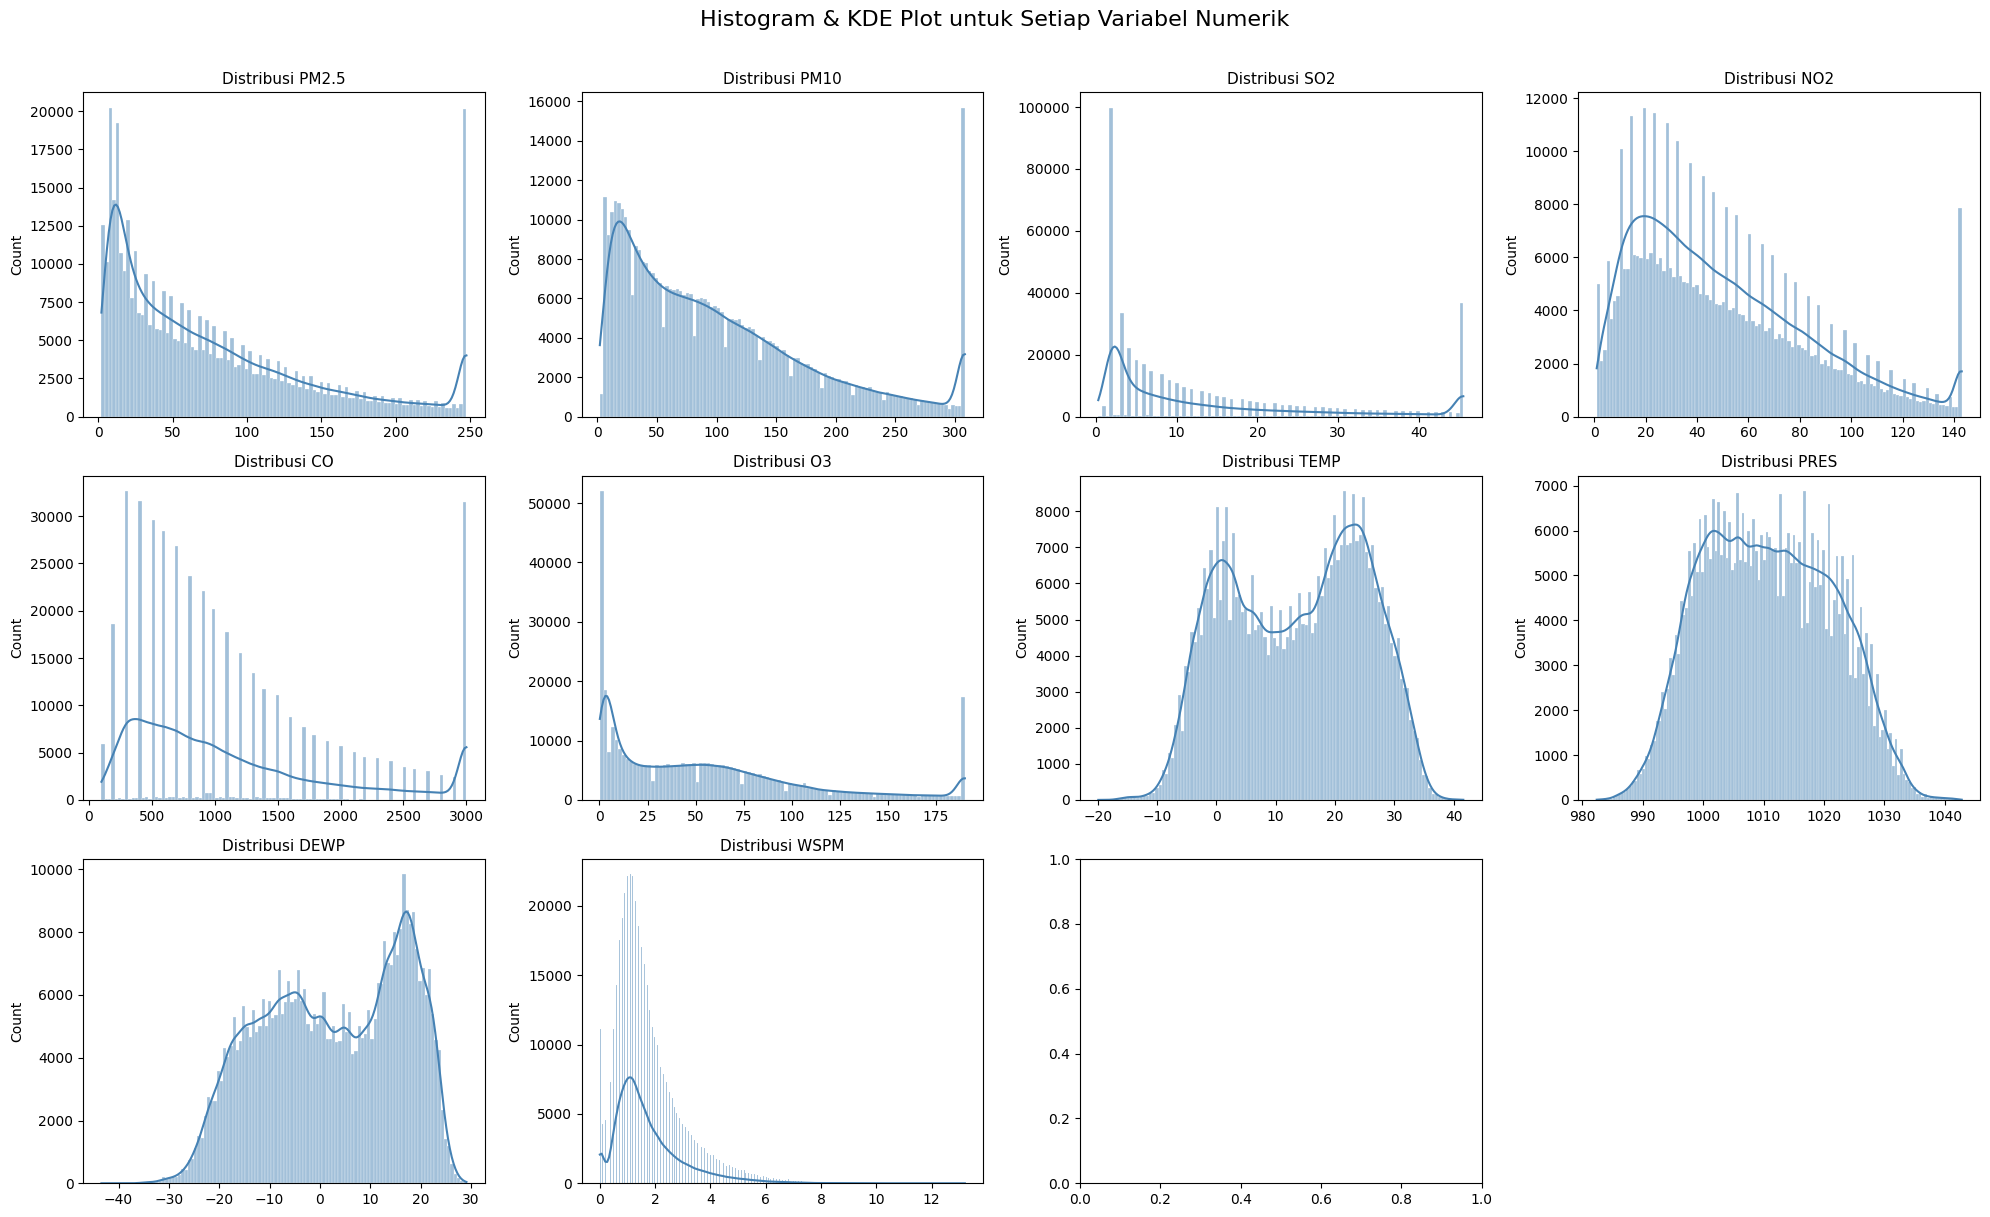

In [24]:
numeric_cols_eda = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'WSPM']

# Histogram + KDE Plot
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols_eda):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribusi {col}', fontsize=11)
    axes[i].set_xlabel(None)

axes[-1].set_visible(False)
plt.suptitle("Histogram & KDE Plot untuk Setiap Variabel Numerik", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


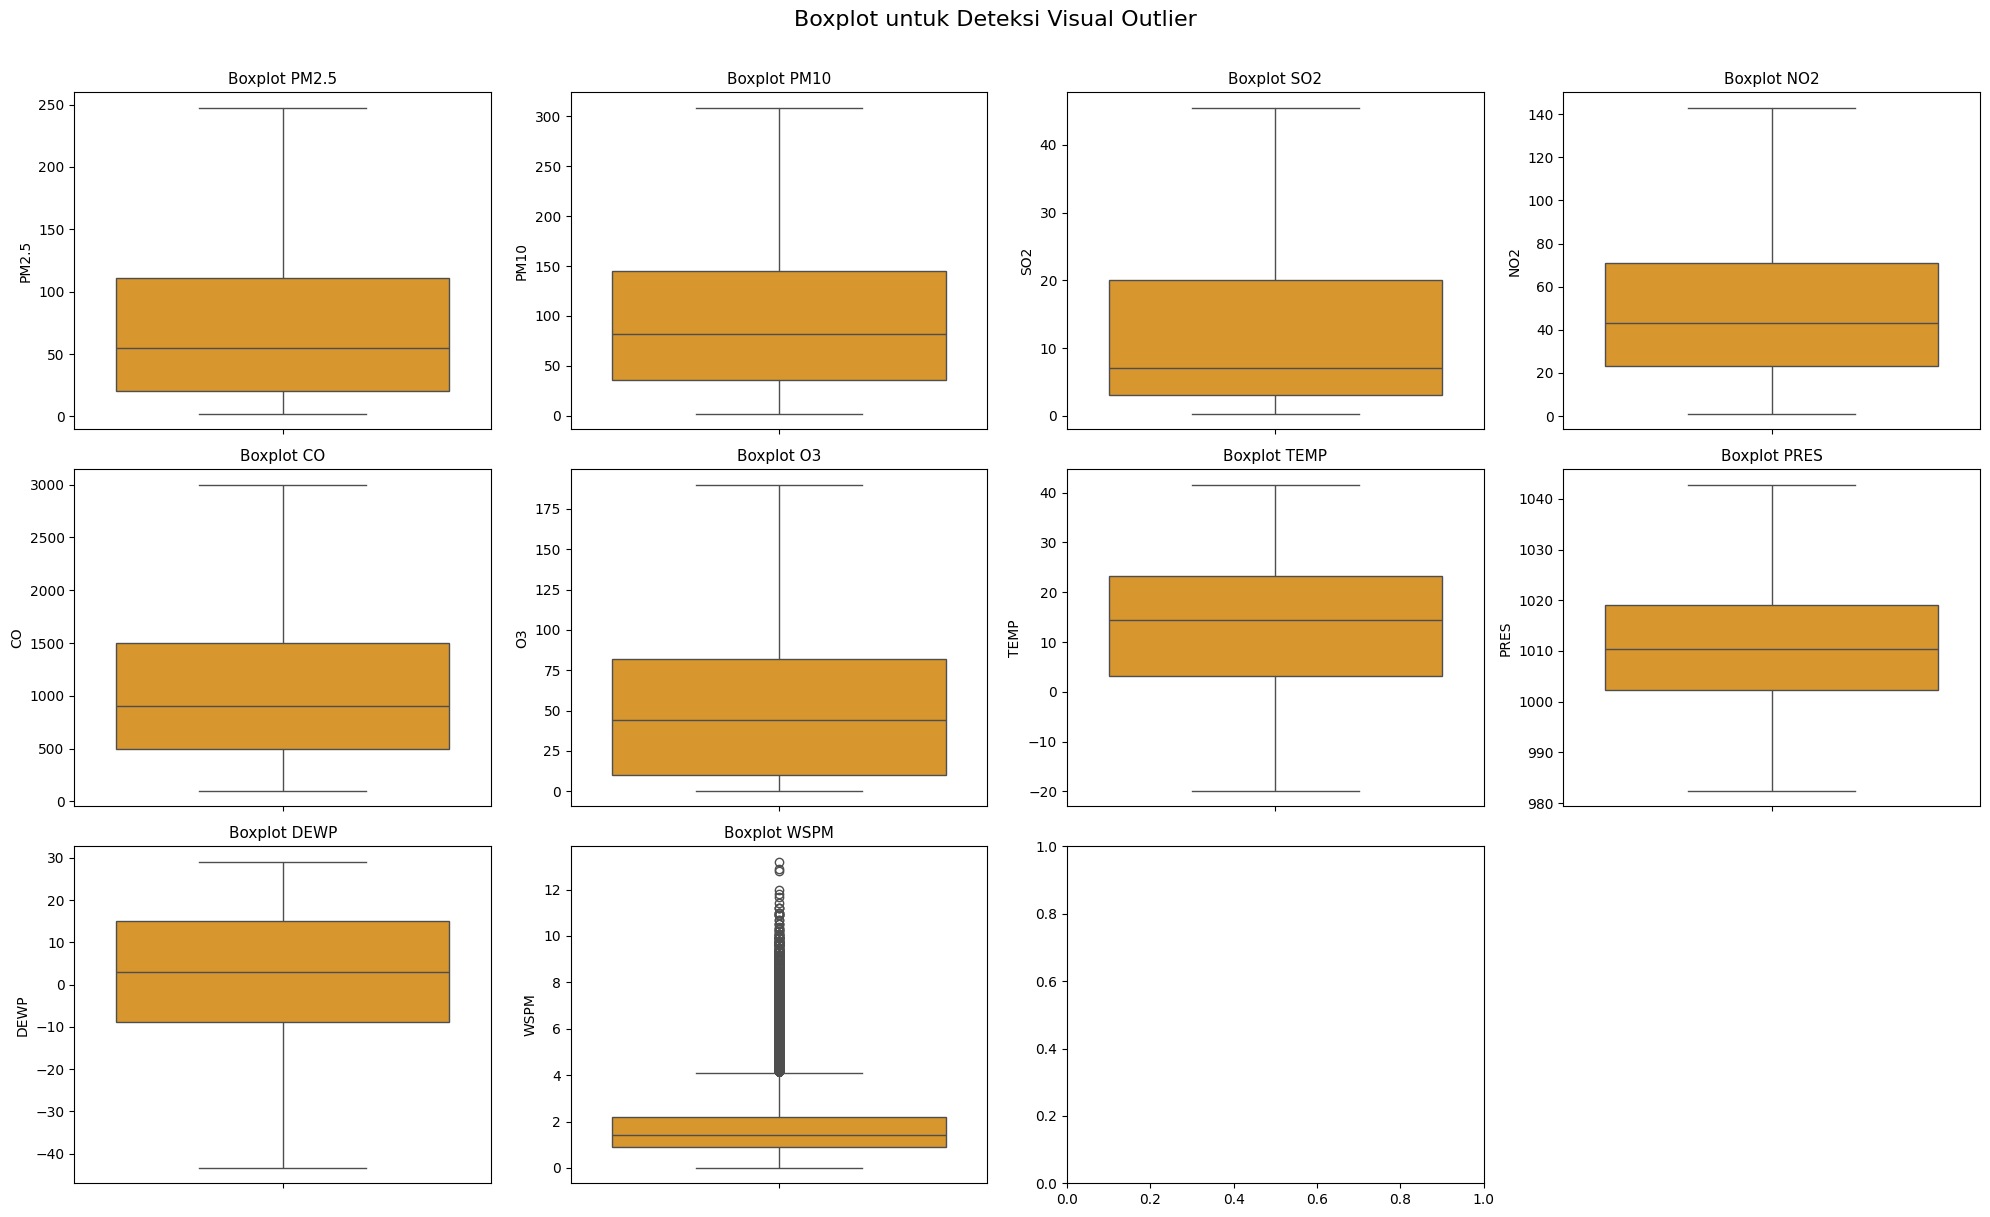

In [25]:
# Boxplot untuk Deteksi Outlier
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols_eda):
    sns.boxplot(y=df[col], ax=axes[i], color='#f39c12')
    axes[i].set_title(f'Boxplot {col}', fontsize=11)

axes[-1].set_visible(False)
plt.suptitle("Boxplot untuk Deteksi Visual Outlier", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


In [26]:
# Skewness dan Kurtosis

for col in numeric_cols_eda:
    skew_val = df[col].skew()
    kurt_val = df[col].kurtosis()
    print(f"{col:<6} | Skewness: {skew_val:>8.3f} | Kurtosis: {kurt_val:>8.3f}")


PM2.5  | Skewness:    1.096 | Kurtosis:    0.292
PM10   | Skewness:    0.969 | Kurtosis:    0.191
SO2    | Skewness:    1.222 | Kurtosis:    0.197
NO2    | Skewness:    0.805 | Kurtosis:    0.002
CO     | Skewness:    1.014 | Kurtosis:    0.022
O3     | Skewness:    1.050 | Kurtosis:    0.382
TEMP   | Skewness:   -0.103 | Kurtosis:   -1.144
PRES   | Skewness:    0.106 | Kurtosis:   -0.830
DEWP   | Skewness:   -0.187 | Kurtosis:   -1.133
WSPM   | Skewness:    1.626 | Kurtosis:    3.685


#### EDA Multivariate

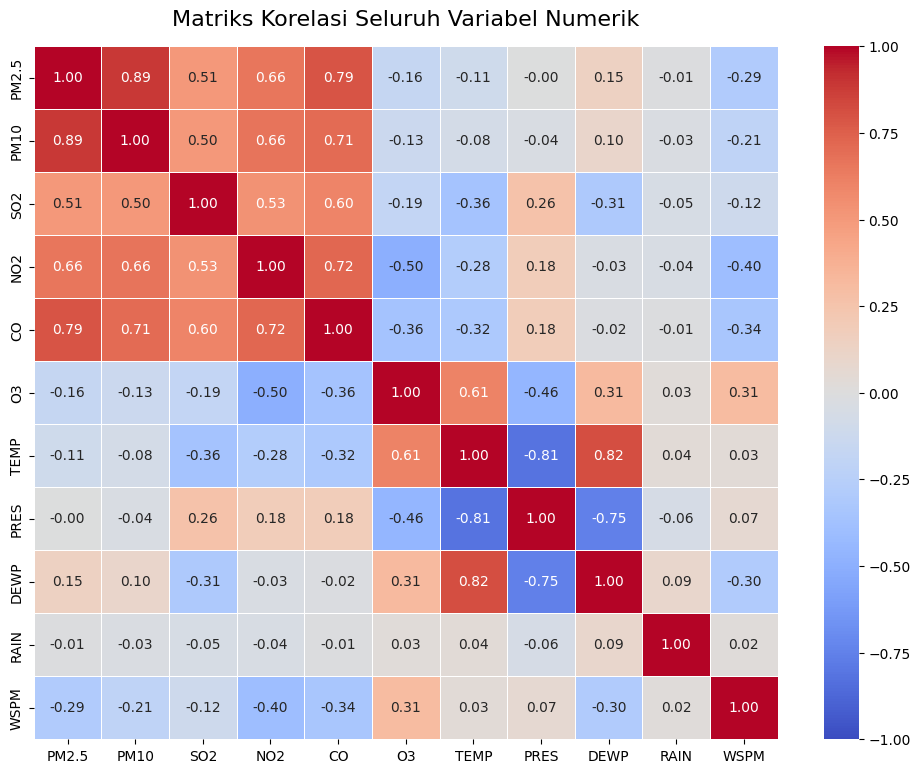

In [27]:
# Correlation Matrix
kolom_numerik_all = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
korelasi_all = df[kolom_numerik_all].corr()
plt.figure(figsize=(12, 9))
sns.heatmap(
    data=korelasi_all,
    annot=True,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Matriks Korelasi Seluruh Variabel Numerik", fontsize=16, pad=15)
plt.show()

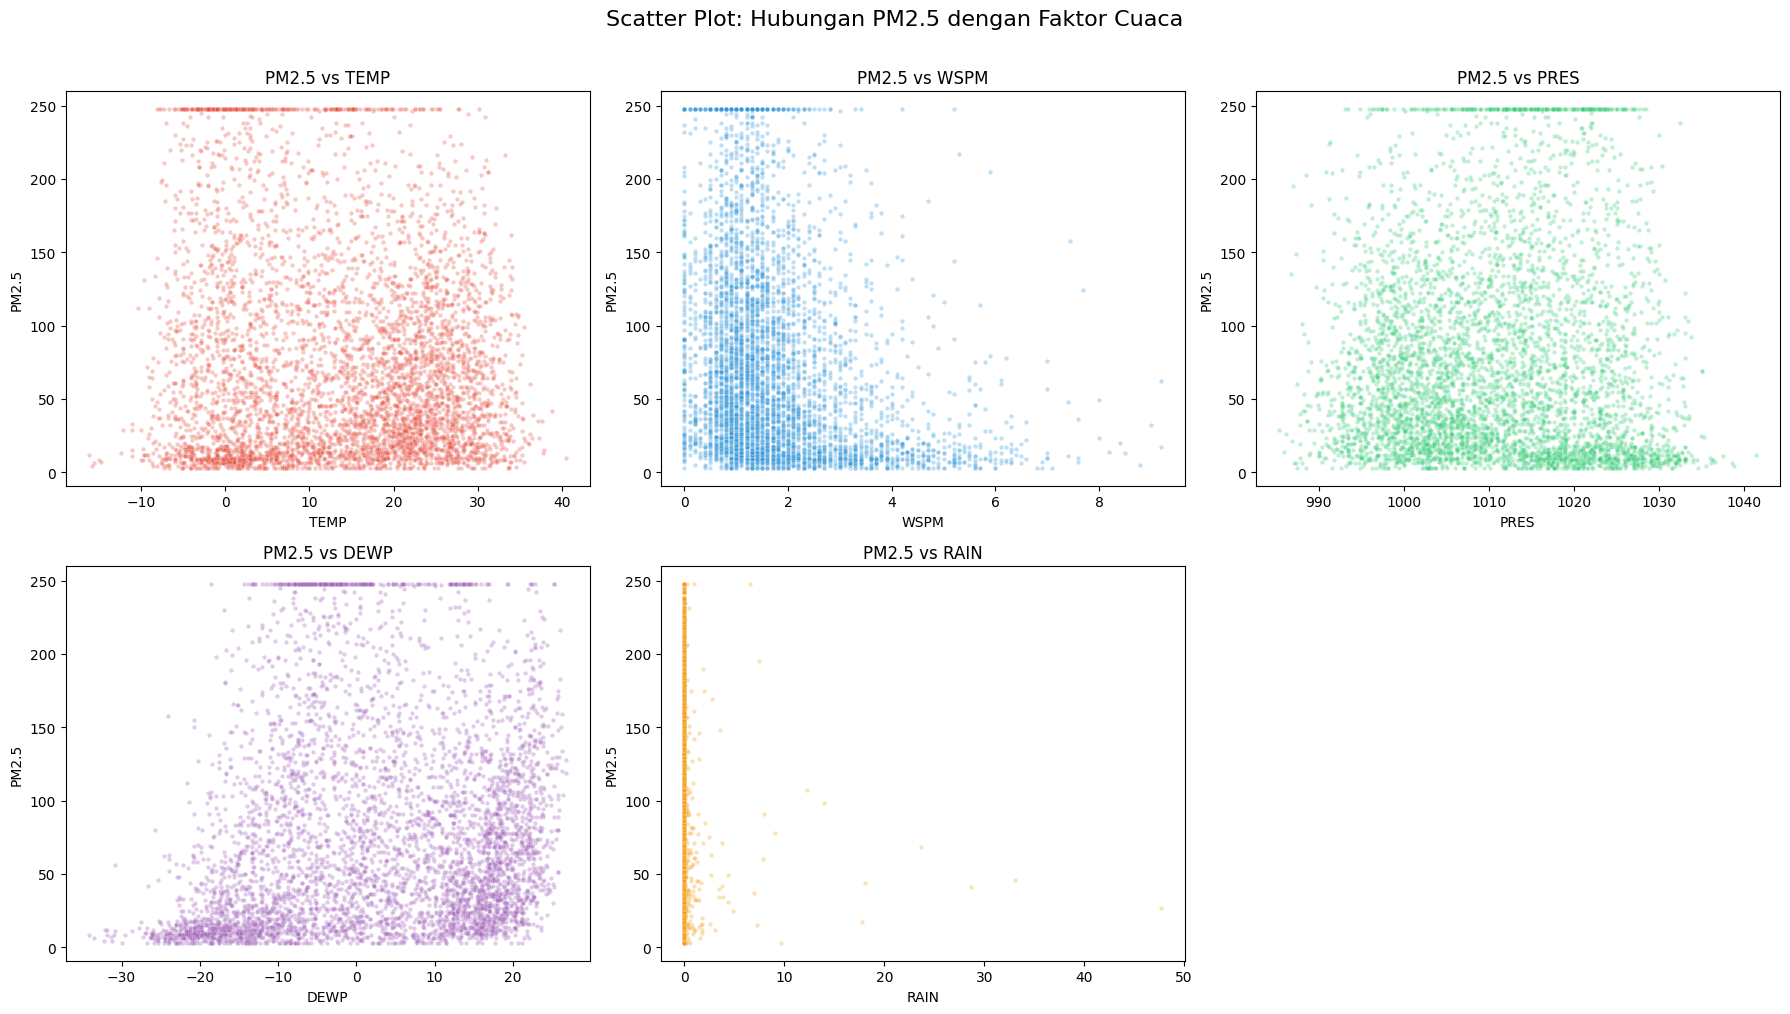

In [28]:
# Scatter plot hubungan PM2.5 dengan faktor cuaca
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

scatter_vars = ['TEMP', 'WSPM', 'PRES', 'DEWP', 'RAIN']
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12']

sample_df = df.sample(5000, random_state=42)

for i, col in enumerate(scatter_vars):
    sns.scatterplot(data=sample_df, x=col, y='PM2.5', alpha=0.3, ax=axes[i], color=colors[i], s=10)
    axes[i].set_title(f"PM2.5 vs {col}")

axes[-1].set_visible(False)

plt.suptitle("Scatter Plot: Hubungan PM2.5 dengan Faktor Cuaca", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

#### EDA Numerikal

In [29]:
# Analisis Persentil Detail
print("Analisis Persentil Detail untuk Polutan Utama\n")

percentiles = [25, 50, 75, 95]
for col in ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']:
    vals = [df[col].quantile(p / 100) for p in percentiles]
    print(f"{col}:")
    for p, v in zip(percentiles, vals):
        print(f"  P{p} = {v:.2f}")
    print()


Analisis Persentil Detail untuk Polutan Utama

PM2.5:
  P25 = 20.00
  P50 = 55.00
  P75 = 111.00
  P95 = 242.00

PM10:
  P25 = 36.00
  P50 = 82.00
  P75 = 145.00
  P95 = 280.00

SO2:
  P25 = 3.00
  P50 = 7.00
  P75 = 20.00
  P95 = 45.50

NO2:
  P25 = 23.00
  P50 = 43.00
  P75 = 71.00
  P95 = 117.00

CO:
  P25 = 500.00
  P50 = 900.00
  P75 = 1500.00
  P95 = 3000.00

O3:
  P25 = 10.00
  P50 = 44.00
  P75 = 82.00
  P95 = 178.00



#### EDA Kategorikal

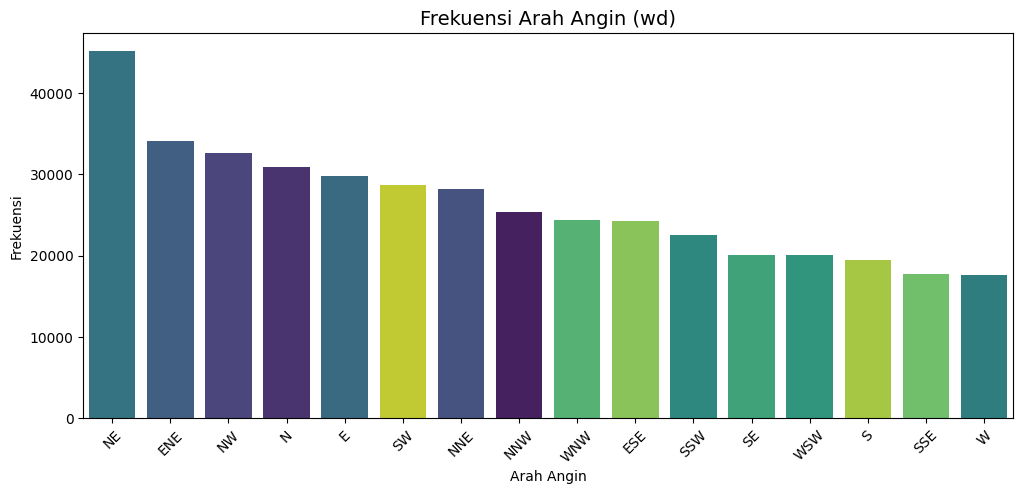

In [30]:
# Countplot: Frekuensi Arah Angin
plt.figure(figsize=(12, 5))
order_wd = df['wd'].value_counts().index
sns.countplot(data=df, x='wd', order=order_wd, hue='wd', palette='viridis', legend=False)
plt.title("Frekuensi Arah Angin (wd)", fontsize=14)
plt.xlabel("Arah Angin")
plt.ylabel("Frekuensi")
plt.xticks(rotation=45)
plt.show()


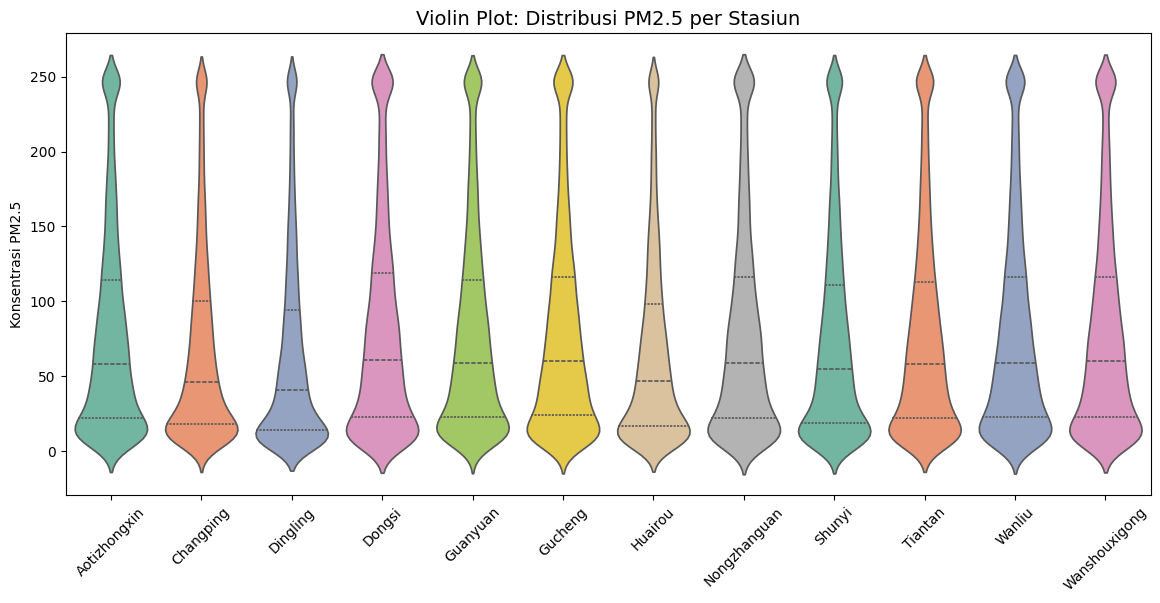

In [31]:
# Violin Plot: PM2.5 per Stasiun
plt.figure(figsize=(14, 6))
sns.violinplot(data=df, x='station', y='PM2.5', hue='station', palette='Set2', legend=False, inner='quartile')
plt.title("Violin Plot: Distribusi PM2.5 per Stasiun", fontsize=14)
plt.xticks(rotation=45)
plt.xlabel(None)
plt.ylabel("Konsentrasi PM2.5")
plt.show()


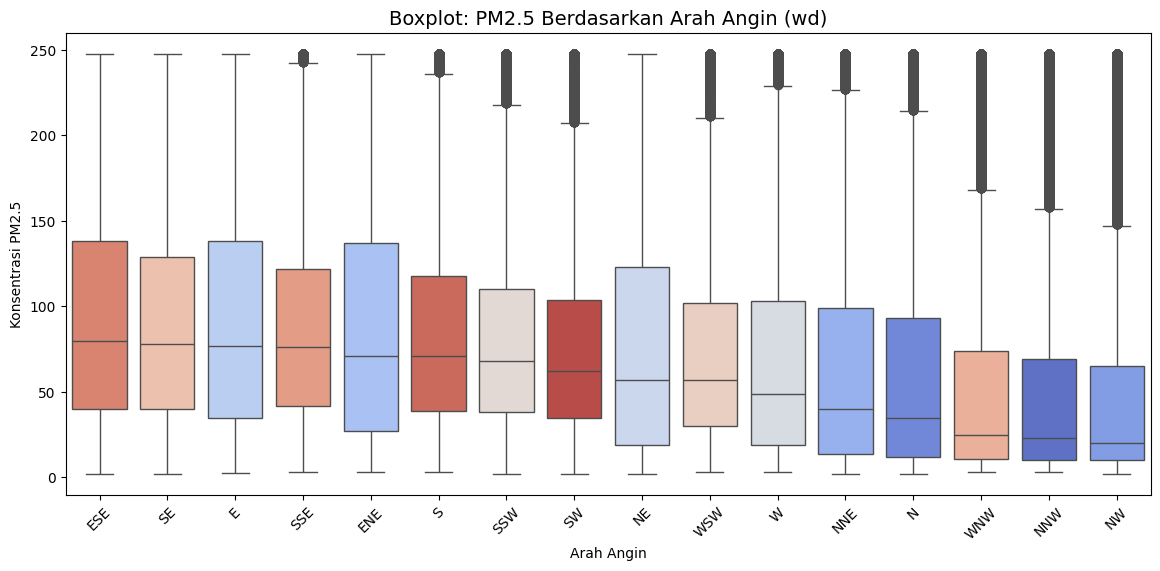

In [32]:
# Boxplot PM2.5 per Arah Angin
plt.figure(figsize=(14, 6))
order_wd_median = df.groupby('wd')['PM2.5'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='wd', y='PM2.5', order=order_wd_median, hue='wd', palette='coolwarm', legend=False)
plt.title("Boxplot: PM2.5 Berdasarkan Arah Angin (wd)", fontsize=14)
plt.xticks(rotation=45)
plt.xlabel("Arah Angin")
plt.ylabel("Konsentrasi PM2.5")
plt.show()


**Insight:** (Opsional)
- xxx
- xxx

## Visualization & Explanatory Analysis

### Pertanyaan 1:

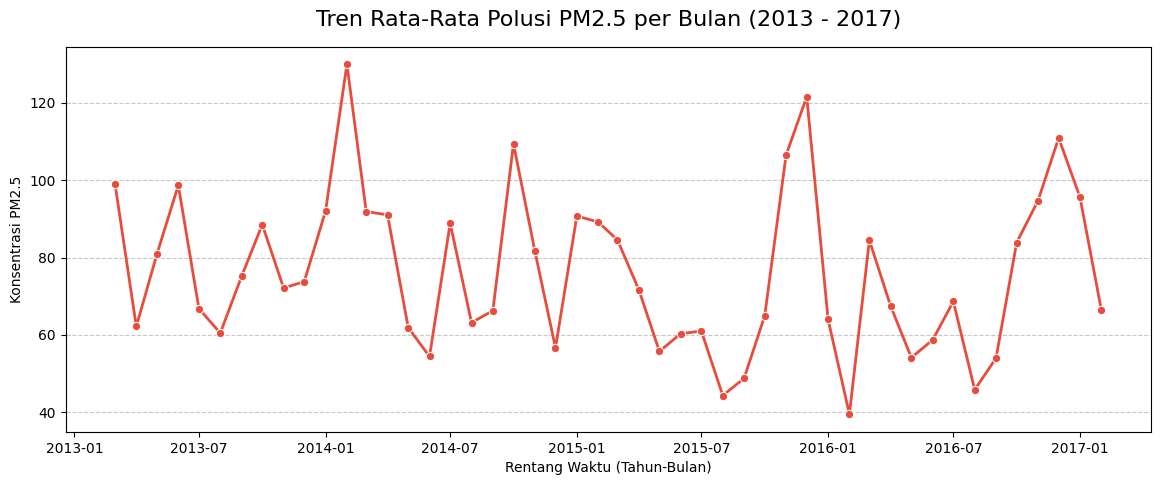

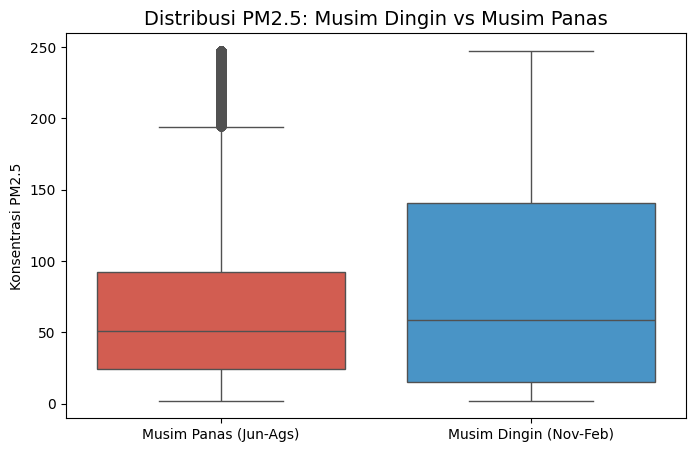

Rata-rata PM2.5 Musim Dingin : 86.60
Rata-rata PM2.5 Musim Panas  : 64.21
Persentase Kenaikan          : 34.9%


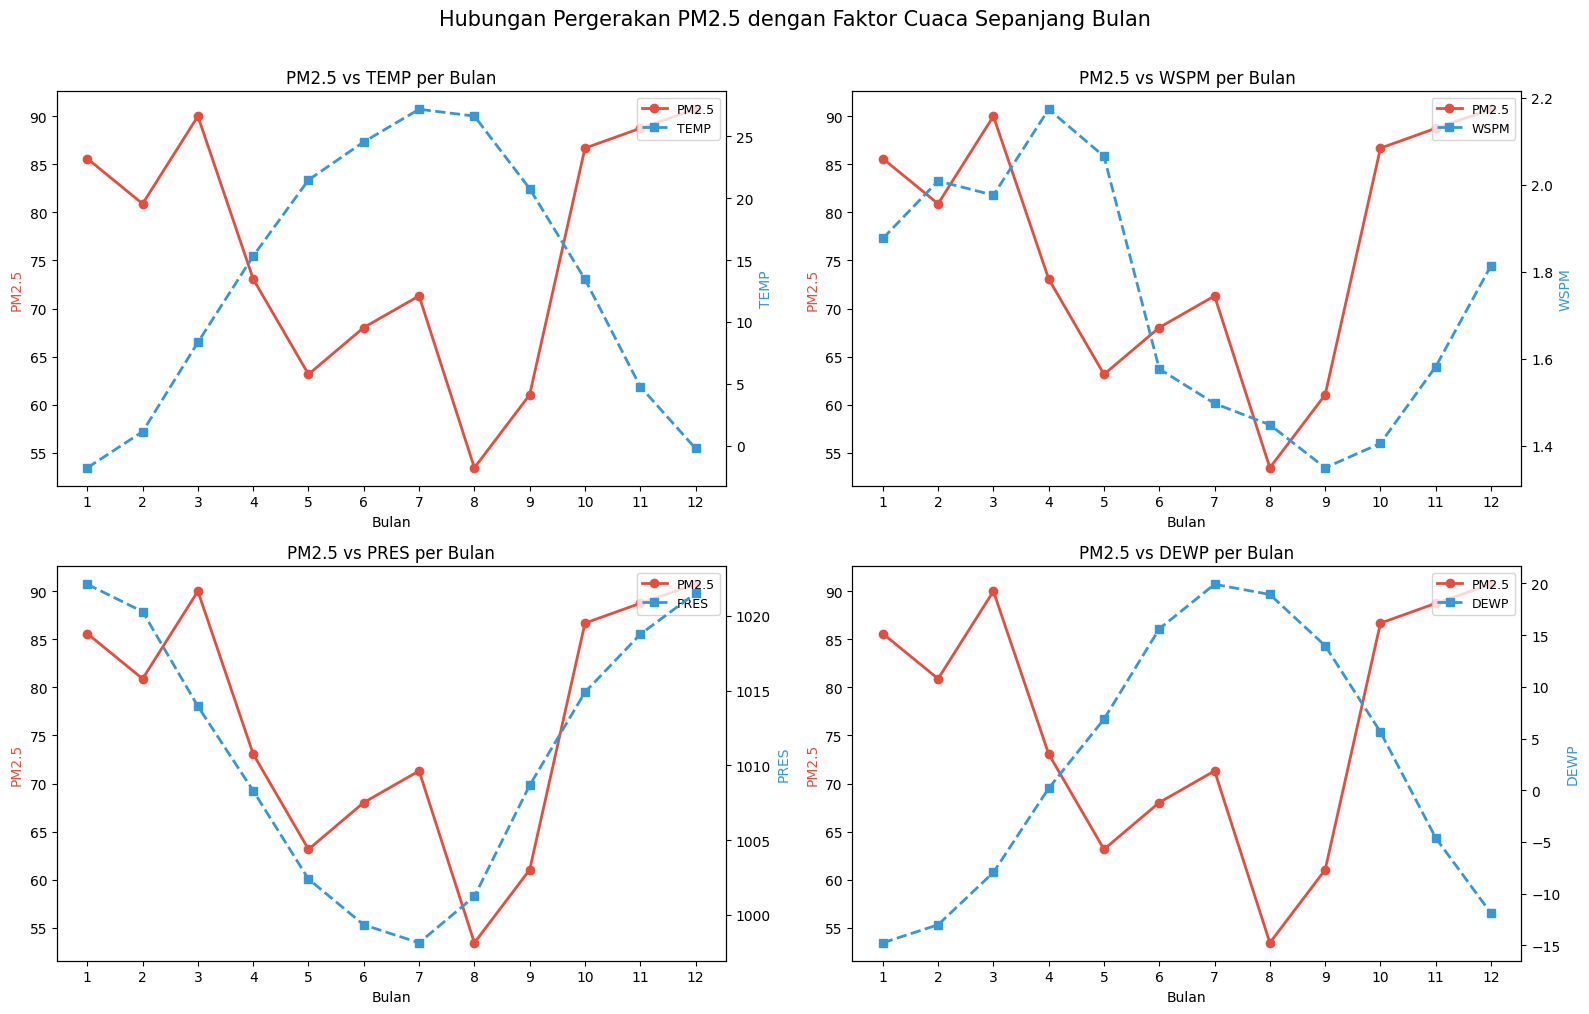

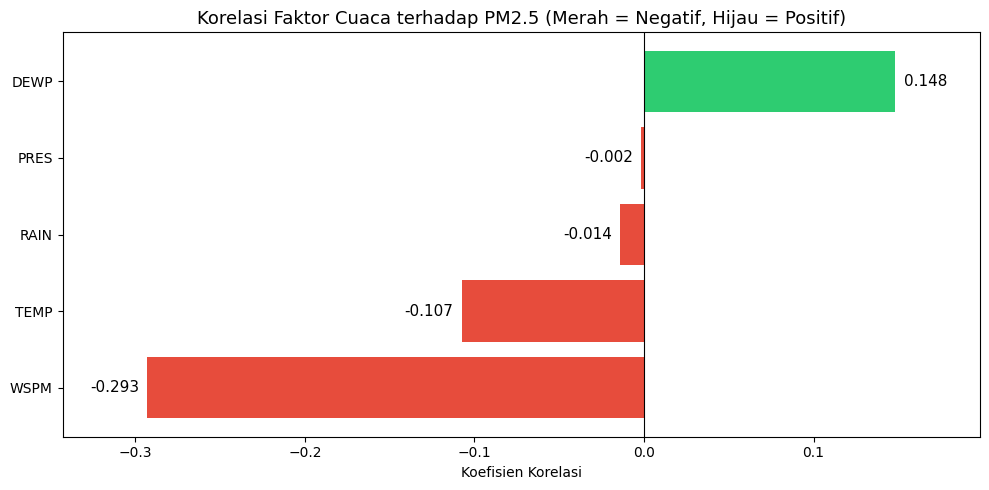

In [40]:
# Tren Rata-Rata PM2.5 per Bulan (Time Series)
tren_bulan_tahun = df.groupby(['year', 'month'])['PM2.5'].mean().reset_index()
tren_bulan_tahun['waktu'] = pd.to_datetime(tren_bulan_tahun[['year', 'month']].assign(DAY=1))

plt.figure(figsize=(14, 5))
sns.lineplot(data=tren_bulan_tahun, x='waktu', y='PM2.5', marker='o', color='#e74c3c', linewidth=2)
plt.title("Tren Rata-Rata Polusi PM2.5 per Bulan (2013 - 2017)", fontsize=16, pad=15)
plt.xlabel("Rentang Waktu (Tahun-Bulan)")
plt.ylabel("Konsentrasi PM2.5")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Bukti Kuantitatif Kenaikan >50% (Musim Dingin vs Musim Panas)
def label_season(month):
    if month in [11, 12, 1, 2]:
        return 'Musim Dingin (Nov-Feb)'
    elif month in [6, 7, 8]:
        return 'Musim Panas (Jun-Ags)'
    else:
        return None

df['season_label'] = df['month'].apply(label_season)
df_filtered = df[df['season_label'].notna()]

season_palette = {'Musim Dingin (Nov-Feb)': '#3498db', 'Musim Panas (Jun-Ags)': '#e74c3c'}

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_filtered, x='season_label', y='PM2.5', hue='season_label',
            palette=season_palette, legend=False)
plt.title("Distribusi PM2.5: Musim Dingin vs Musim Panas", fontsize=14)
plt.xlabel(None)
plt.ylabel("Konsentrasi PM2.5")
plt.show()

mean_winter = df_filtered[df_filtered['season_label'] == 'Musim Dingin (Nov-Feb)']['PM2.5'].mean()
mean_summer = df_filtered[df_filtered['season_label'] == 'Musim Panas (Jun-Ags)']['PM2.5'].mean()
pct = ((mean_winter - mean_summer) / mean_summer) * 100

print(f"Rata-rata PM2.5 Musim Dingin : {mean_winter:.2f}")
print(f"Rata-rata PM2.5 Musim Panas  : {mean_summer:.2f}")
print(f"Persentase Kenaikan          : {pct:.1f}%")

# Pergerakan PM2.5 vs Faktor Cuaca per Bulan
weather_factors = ['TEMP', 'WSPM', 'PRES', 'DEWP']
monthly_mean = df.groupby('month')[['PM2.5'] + weather_factors].mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(weather_factors):
    ax1 = axes[i]
    ax2 = ax1.twinx()

    ax1.plot(monthly_mean.index, monthly_mean['PM2.5'], marker='o', color='#e74c3c', linewidth=2, label='PM2.5')
    ax2.plot(monthly_mean.index, monthly_mean[col], marker='s', color='#3498db', linewidth=2, linestyle='--', label=col)

    ax1.set_ylabel('PM2.5', color='#e74c3c')
    ax2.set_ylabel(col, color='#3498db')
    ax1.set_xlabel('Bulan')
    ax1.set_xticks(range(1, 13))
    ax1.set_title(f"PM2.5 vs {col} per Bulan", fontsize=12)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

plt.suptitle("Hubungan Pergerakan PM2.5 dengan Faktor Cuaca Sepanjang Bulan", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()


# Korelasi Faktor Cuaca yang Memengaruhi PM2.5
weather_cols = ['TEMP', 'WSPM', 'PRES', 'DEWP', 'RAIN']
corr_values = df[weather_cols].corrwith(df['PM2.5']).sort_values()

colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_values]

plt.figure(figsize=(10, 5))
bars = plt.barh(corr_values.index, corr_values.values, color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title("Korelasi Faktor Cuaca terhadap PM2.5 (Merah = Negatif, Hijau = Positif)", fontsize=13)
plt.xlabel("Koefisien Korelasi")

# Penempatan teks yang lebih rapi dan dinamis
for bar, val in zip(bars, corr_values.values):
    if val >= 0:
        # Untuk nilai positif, teks diletakkan di sebelah kanan bar
        plt.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', ha='left', fontsize=11)
    else:
        # Untuk nilai negatif, teks diletakkan di sebelah kiri bar
        plt.text(val - 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', ha='right', fontsize=11)

# Tambahkan margin ekstra pada sumbu X agar teks tidak menabrak label/batas
plt.xlim(corr_values.min() - 0.05, corr_values.max() + 0.05)

plt.tight_layout()
plt.show()


### Pertanyaan 2:

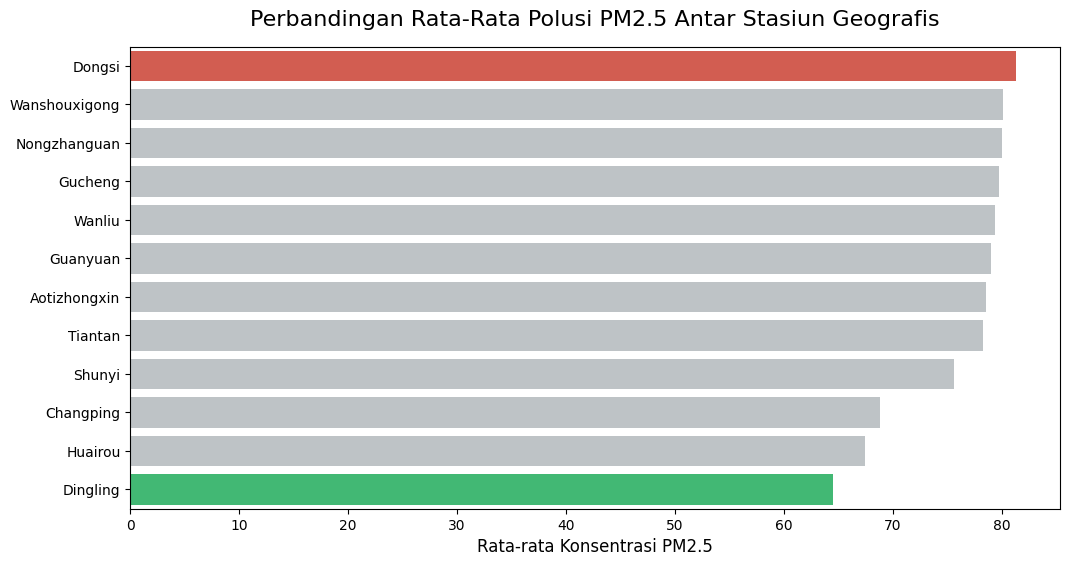

In [34]:
# Ambil Rata-rata PM2.5 ditarik per nama stasiun
stasiun_df = df.groupby('station')['PM2.5'].mean().sort_values(ascending=False).reset_index()

# Menyiapkan skema warna: Merah untuk tertinggi, Hijau terendah, abu-abu sisanya
station_terburuk = stasiun_df['station'].iloc[0]
station_terbaik = stasiun_df['station'].iloc[-1]
warna = ['#e74c3c' if s == station_terburuk else '#2ecc71' if s == station_terbaik else '#bdc3c7' for s in stasiun_df['station']]

# Render Bar Chart Horizontal
plt.figure(figsize=(12, 6))
sns.barplot(data=stasiun_df, x='PM2.5', y='station', hue = 'station', palette=warna)

plt.title("Perbandingan Rata-Rata Polusi PM2.5 Antar Stasiun Geografis", fontsize=16, pad=15)
plt.xlabel("Rata-rata Konsentrasi PM2.5", fontsize=12)
plt.ylabel(None) # Menghilangkan label sumbu Y agar lebih bersih
plt.show()


**Insight:** (Opsional)
- **Tren Musiman Polusi (Pertanyaan 1):** Konsentrasi PM2.5 di Beijing selalu melonjak >25% pada musim dingin (Nov-Feb) dibanding musim panas akibat rendahnya suhu (TEMP) dan lemahnya kecepatan angin (WSPM). Oleh karena itu, pemerintah wajib memperketat regulasi emisi secara spesifik pada 4 bulan kritis tersebut.

- **Perbedaan Kualitas Udara Antar Wilayah (Pertanyaan 2):** Stasiun pengamatan Dongsi secara konsisten menduduki peringkat pertama dengan beban polusi PM2.5 tertinggi, mencatat *gap* konsentrasi yang signifikan dibandingkan stasiun Dingling (terbersih). Pemerintah perlu memprioritaskan alokasi dana dan intervensi lingkungan langsung ke wilayah Dongsi.

## Analisis Lanjutan (Opsional)

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Berdasarkan fluktuasi rata-rata polutan dari waktu ke waktu, kesimpulannya adalah rentang waktu kalender (seasonality/musim) sangat mendikte tingkat keparahan polusi udara. Fenomena polusi paling parah menumpuk setiap transisi ke musim dingin (November hingga Februari), yang sangat mungkin disebabkan oleh pembakaran batu bara/pemanas ruangan massal yang pekat. Akan tetapi, tingkat polusi secara drastis luluh termitigasi pada siklus pertengahan tahun (Juli hingga Agustus) saat musim panas berlangsung.
- **Conclusion pertanyaan 2:** Secara spasial stasiun pengawasan Dongsi adalah pusat penumpukan polusi terburuk dengan paparan harian PM2.5 yang konstan mendominasi secara absolut. Sebaliknya, wilayah perdesaan/eksterior yang dihuni oleh stasiun percontohan Dingling menduduki tahta sebagai kawasan dengan suplai udara paling asri dan minim tercemar partikel halus, membuktikan adanya jurang (gap) kualitas udara yang jauh antara tata letak terpusat (kota padat) vs pinggiran kota.

**Rekomendasi Action Item:**
- Pemberlakuan Kebijakan Pengetatan Ekstraketat di Musim Dingin: Karena beban polisi terekam memuncak tajam di bulan November hingga Februari (kuartal pancaroba/musim dingin), stakeholder atau pemerintah diimbau untuk memfokuskan alokasi regulasi ketat (seperti membatasi pembakaran batubara, memberlakukan work-from-home massal saat indeks bahaya, atau subsidi penghangat ramah lingkungan) secara eksklusif hanya pada 4 bulan krusial tersebut guna menekan pengeluaran logistik.
- Intervensi Prioritas pada Zona Merah (Dongsi): Memprioritaskan zona stasiun Dongsi sebagai fokus revitalisasi lingkungan secara mendesak. Tindakan korektif dapat berupa razia emisi gas buang kendaraan, relokasi pabrik perakitan yang dekat dengan stasiun, dan rekayasa jalur lalu lintas. Sebaliknya, wilayah Dingling dapat diorbitkan rekomendasinya ke publik sebagai contoh "kawasan sehat bebas PM2.5" atau dijadikan model acuan (benchmark) bagi tata letak ruang hijau di masa depan.